In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
df = pd.read_csv('/content/bank.csv')

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


In [ ]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
print("=== Umumiy statistika ===")
print(df.describe())

print("\n=== Kategorik ustunlar ===")
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique qiymat")
    print(df[col].value_counts())

print("\n=== Target (deposit) taqsimoti ===")
print(df['deposit'].value_counts())
print(df['deposit'].value_counts(normalize=True).round(3) * 100)

=== Umumiy statistika ===
                age       balance           day      duration      campaign  \
count  11162.000000  11162.000000  11162.000000  11162.000000  11162.000000   
mean      41.231948   1528.538524     15.658036    371.993818      2.508421   
std       11.913369   3225.413326      8.420740    347.128386      2.722077   
min       18.000000  -6847.000000      1.000000      2.000000      1.000000   
25%       32.000000    122.000000      8.000000    138.000000      1.000000   
50%       39.000000    550.000000     15.000000    255.000000      2.000000   
75%       49.000000   1708.000000     22.000000    496.000000      3.000000   
max       95.000000  81204.000000     31.000000   3881.000000     63.000000   

              pdays      previous  
count  11162.000000  11162.000000  
mean      51.330407      0.832557  
std      108.758282      2.292007  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%       

In [ ]:
# Yosh guruhlari
df['age_group'] = pd.cut(df['age'],
    bins=[0, 25, 35, 50, 65, 100],
    labels=['18-25', '26-35', '36-50', '51-65', '65+'])

# Balans kategoriyasi
df['balance_category'] = pd.cut(df['balance'],
    bins=[-np.inf, 0, 1000, 5000, np.inf],
    labels=['Salbiy', 'Past', "O'rta", 'Yuqori'])

# Kredit yuki (housing yoki loan bor)
df['debt_flag'] = ((df['housing'] == 'yes') |
                   (df['loan'] == 'yes')).astype(int)

# Oldingi kampaniya muvaffaqiyati
df['prev_success'] = (df['poutcome'] == 'success').astype(int)

print("Yangi ustunlar qo'shildi:")
print(df[['age_group','balance_category','debt_flag','prev_success']].head())

Yangi ustunlar qo'shildi:
  age_group balance_category  debt_flag  prev_success
0     51-65            O'rta          1             0
1     51-65             Past          0             0
2     36-50            O'rta          1             0
3     51-65            O'rta          1             0
4     51-65             Past          0             0


/tmp/ipykernel_2044/2134627963.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(edu_dep.index, rotation=20)
/tmp/ipykernel_2044/2134627963.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2,1].set_xticklabels(month_order, rotation=45)


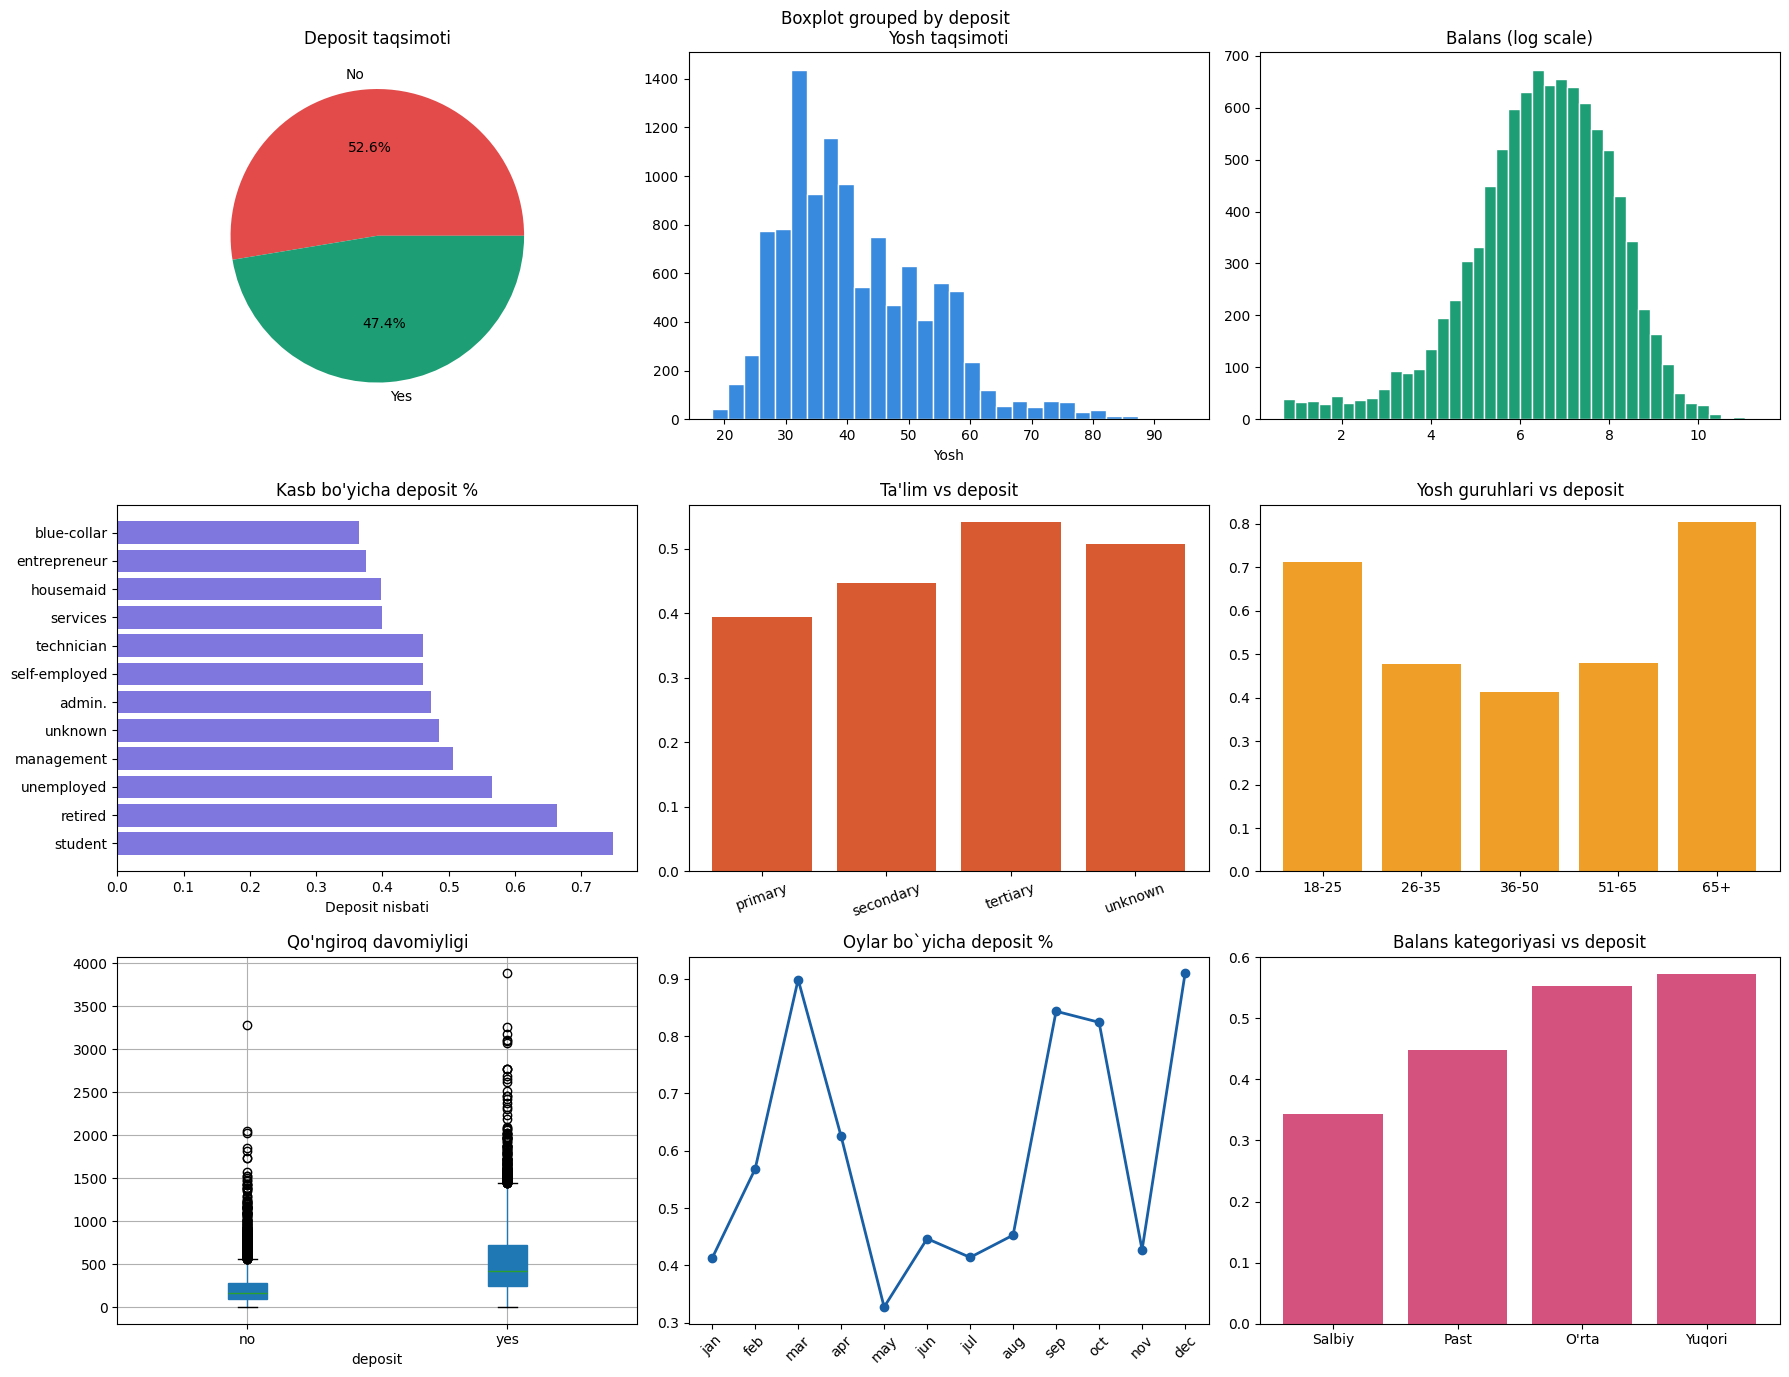

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Bank Marketing EDA', fontsize=16, fontweight='bold')

# 1. Target taqsimoti
axes[0,0].pie(df['deposit'].value_counts(),
    labels=['No','Yes'], autopct='%1.1f%%',
    colors=['#E24B4A','#1D9E75'])
axes[0,0].set_title('Deposit taqsimoti')

# 2. Yosh taqsimoti
axes[0,1].hist(df['age'], bins=30, color='#378ADD', edgecolor='white')
axes[0,1].set_title('Yosh taqsimoti')
axes[0,1].set_xlabel('Yosh')

# 3. Balans taqsimoti (log scale)
pos_balance = df[df['balance'] > 0]['balance']
axes[0,2].hist(np.log1p(pos_balance), bins=40, color='#1D9E75', edgecolor='white')
axes[0,2].set_title('Balans (log scale)')

# 4. Kasblar vs deposit
job_dep = df.groupby('job')['deposit'].apply(
    lambda x: (x=='yes').mean()).sort_values(ascending=False)
axes[1,0].barh(job_dep.index, job_dep.values, color='#7F77DD')
axes[1,0].set_title("Kasb bo'yicha deposit %")
axes[1,0].set_xlabel('Deposit nisbati')

# 5. Ta'lim vs deposit
edu_dep = df.groupby('education')['deposit'].apply(
    lambda x: (x=='yes').mean())
axes[1,1].bar(edu_dep.index, edu_dep.values, color='#D85A30')
axes[1,1].set_title("Ta'lim vs deposit")
axes[1,1].set_xticklabels(edu_dep.index, rotation=20)

# 6. Yosh guruhlari vs deposit
age_dep = df.groupby('age_group', observed=True)['deposit'].apply(
    lambda x: (x=='yes').mean())
axes[1,2].bar(age_dep.index.astype(str), age_dep.values, color='#EF9F27')
axes[1,2].set_title('Yosh guruhlari vs deposit')

# 7. Duration boxplot
df.boxplot(column='duration', by='deposit', ax=axes[2,0],
    patch_artist=True)
axes[2,0].set_title("Qo'ngiroq davomiyligi")

# 8. Oylar bo'yicha kampaniya
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
month_dep = df.groupby('month')['deposit'].apply(
    lambda x: (x=='yes').mean()).reindex(month_order)
axes[2,1].plot(month_dep.index, month_dep.values,
    marker='o', color='#185FA5', linewidth=2)
axes[2,1].set_title('Oylar bo`yicha deposit %')
axes[2,1].set_xticklabels(month_order, rotation=45)

# 9. Balans kategoriyasi vs deposit
bal_dep = df.groupby('balance_category', observed=True)['deposit'].apply(
    lambda x: (x=='yes').mean())
axes[2,2].bar(bal_dep.index.astype(str), bal_dep.values, color='#D4537E')
axes[2,2].set_title('Balans kategoriyasi vs deposit')

plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()

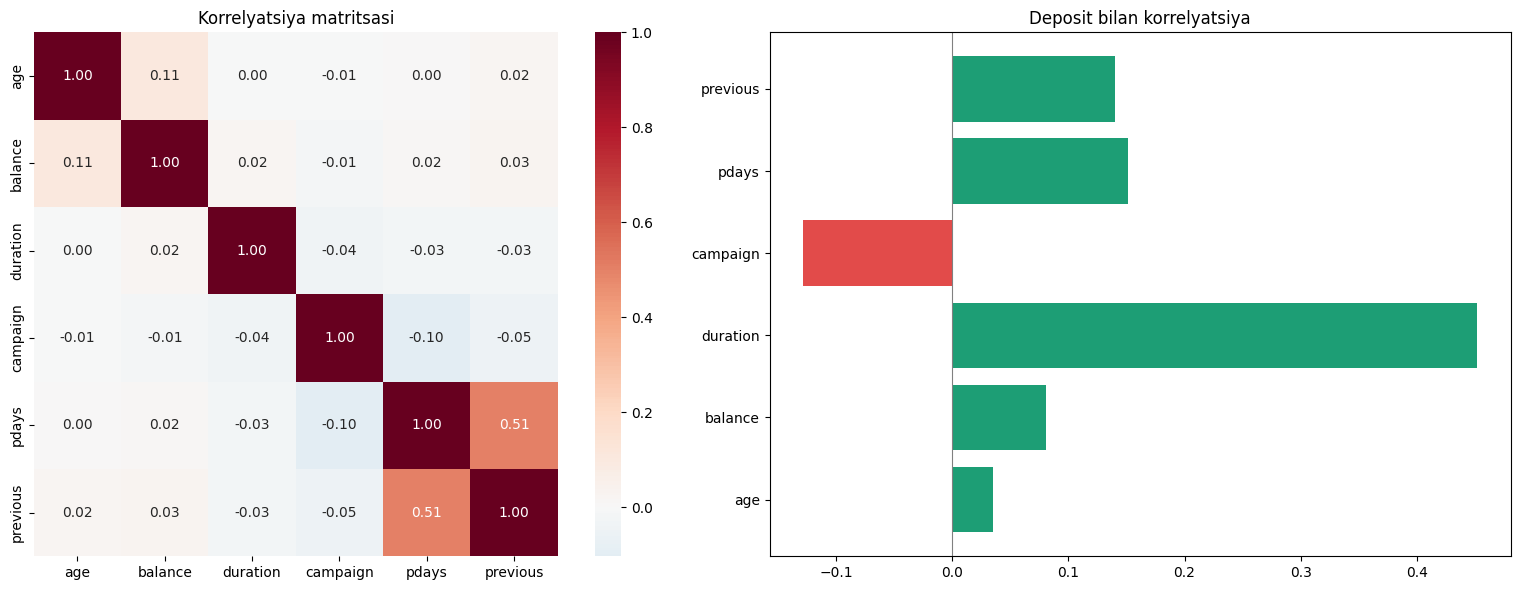


Deposit bilan korrelyatsiya (tartiblangan):
duration    0.451919
pdays       0.151593
previous    0.139867
campaign    0.128081
balance     0.081129
age         0.034901
Name: deposit_num, dtype: float64


In [ ]:
num_cols = ['age','balance','duration','campaign','pdays','previous']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Korrelyatsiya matritsasi
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=axes[0], square=True)
axes[0].set_title('Korrelyatsiya matritsasi')

# Deposit bilan korrelyatsiya
df['deposit_num'] = (df['deposit'] == 'yes').astype(int)
dep_corr = df[num_cols + ['deposit_num']].corr()['deposit_num'].drop('deposit_num')
colors = ['#1D9E75' if v > 0 else '#E24B4A' for v in dep_corr.values]
axes[1].barh(dep_corr.index, dep_corr.values, color=colors)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_title("Deposit bilan korrelyatsiya")

plt.tight_layout()
plt.savefig('correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDeposit bilan korrelyatsiya (tartiblangan):")
print(dep_corr.abs().sort_values(ascending=False))

In [ ]:
df

,age,job,marital,education,default,balance,housing,loan,contact,day,...,campaign,pdays,previous,poutcome,deposit,age_group,balance_category,debt_flag,prev_success,deposit_num
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,...,1,-1,0,unknown,yes,51-65,O'rta,1,0,1
1,56,admin.,married,secondary,no,45,no,no,unknown,5,...,1,-1,0,unknown,yes,51-65,Past,0,0,1
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,...,1,-1,0,unknown,yes,36-50,O'rta,1,0,1
3,55,services,married,secondary,no,2476,yes,no,unknown,5,...,1,-1,0,unknown,yes,51-65,O'rta,1,0,1
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,...,2,-1,0,unknown,yes,51-65,Past,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,...,1,-1,0,unknown,no,26-35,Past,1,0,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,...,4,-1,0,unknown,no,36-50,Past,0,0,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,...,2,-1,0,unknown,no,26-35,Past,0,0,0
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,...,2,172,5,failure,no,36-50,Salbiy,1,0,0


In [ ]:
df.to_csv('bank2.csv')